# **IUCN distribution - ACUS**

Author: Daning Montaño - Ocampo

Kernel: R

# **1. Packages and libraries**

In [1]:
suppressMessages({
  library(dplyr)
  library(ggplot2)
  library(sf)
  library(iNEXT)
  library(tidyr)
  library(vegan)
  library(tibble)
  library(gstat)
  library(ggplot2)
  library(purrr)
  library(stringr)
  library(bdc)
  library(openxlsx)
  library(units)
  })
  #library(doParallel)
  #

Warning messages:
1: package ‘dplyr’ was built under R version 4.3.3 
2: package ‘iNEXT’ was built under R version 4.3.3 
3: package ‘tidyr’ was built under R version 4.3.3 
4: package ‘units’ was built under R version 4.3.3 


# **2.Load data**

## 2.1. Grids

In [2]:

grids_1km_buffer = st_read("../../../DATOS/SHP/Grids/grid_zamora_ch_buffer_1km.shp")
AOI = st_read("../../../DATOS/SHP/Limites_politicos/Provincia_ZCh_5km_buffer.shp")

Reading layer `grid_zamora_ch_buffer_1km' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Grids\grid_zamora_ch_buffer_1km.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 15779 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 675083.7 ymin: 9444351 xmax: 794083.7 ymax: 9631351
Projected CRS: WGS 84 / UTM zone 17S
Reading layer `Provincia_ZCh_5km_buffer' from data source 
  `C:\PROYECTOS\consultorias\ACUS DIAGNOSTICO\DATOS\SHP\Limites_politicos\Provincia_ZCh_5km_buffer.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1 feature and 7 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 664270.2 ymin: 9435300 xmax: 802756.4 ymax: 9640425
Projected CRS: WGS 84 / UTM zone 17S


## 2.2. List of distribution files

In [3]:
list_iucn_files = list.files("../../../DATOS/SHP/Biodiversidad/IUCN_distributions")

list_iucn_files_shp = list_iucn_files[grepl("\\.shp$", list_iucn_files)]
list_iucn_files_shp

[1] "amphibians_1.shp" "amphibians_2.shp" "birds_all.shp"    "mammals_1.shp"   
[5] "mammals_2.shp"    "plantas_1.shp"    "plantas_2.shp"    "reptiles_1.shp"  
[9] "reptiles_2.shp"  

## 2.3. Red List

In [4]:
iucn_red_list = read.xlsx("../../../DATOS/Datasets/Biodiversidad/tabla_biodiversidad_ecuador_redlists_all_gbif.xlsx")|>
  select(Estado_conservacion,  sci_name_gbif)|>
  mutate(scientificName = sci_name_gbif )|>
  select(-sci_name_gbif)

# **3. Join data**

## 3.1. Join all distributions

In [5]:

# listar shp
list_iucn_files <- list.files(
  "../../../DATOS/SHP/Biodiversidad/IUCN_distributions",
  pattern = "\\.shp$",
  full.names = TRUE
)

# leer, reproyectar a UTM 17S (EPSG:32717) y agregar nombre de archivo
iucn_list <- map(list_iucn_files, function(f) {
  st_read(f, quiet = TRUE) |>
    st_transform(32717) |>
    mutate(source_file = str_remove(basename(f), "\\.shp$"))
})

# unir todo en un solo objeto
iucn_all <- bind_rows(iucn_list)


## 3.2. Add group value

In [6]:
iucn_all <- iucn_all %>%
  dplyr::mutate(
    Group = dplyr::case_when(
      source_file == "birds_all" ~ "Aves",
      source_file == "reptiles_1" ~ "Reptiles",
      source_file == "reptiles_2" ~ "Reptiles",
      source_file == "amphibians_1" ~ "Anfibios",
      source_file == "amphibians_2" ~ "Anfibios",
      source_file == "plantas_1" ~ "Plantas",
      source_file == "plantas_2" ~ "Plantas",
      source_file == "mammals_1" ~ "Mamíferos",
      source_file == "mammals_2" ~ "Mamíferos",
      TRUE ~ NA_character_
    )
  )


# **4.Transform names - GBIF Backbone**

## 4.1 Extract names

In [7]:
sp_plants = iucn_all |>
  dplyr::filter(Group == "Plantas")|>
  pull(sci_name)|>
  unique()|>
  na.omit()



sp_birds = iucn_all |>
  dplyr::filter(Group == "Aves"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()


sp_mammals = iucn_all |>
  dplyr::filter(Group == "Mamíferos"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()


sp_amphibia = iucn_all |>
  dplyr::filter(Group == "Anfibios"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()

sp_squamata = iucn_all |>
  dplyr::filter(Group == "Reptiles"
  )|>
      pull(sci_name)|>
      unique()|>
        na.omit()

## 4.2 Plants

In [8]:
length(sp_plants)

[1] 95

In [9]:
query_names_plants <- bdc_query_names_taxadb(
  sci_name            = sp_plants,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Plantae",
  rank                = "kingdom",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 95 names queried in 0.2 minutes



In [10]:
query_names_plants = query_names_plants %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_gbif = query_names_plants%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_gbif

# A tibble: 6 × 3
  notes                                 n  prop
  <chr>                             <int> <dbl>
1 accepted                             86 90.5 
2 accepted | replaceSynonym             5  5.26
3 heterotypic synonym                   1  1.05
4 homotypic synonym                     1  1.05
5 homotypic synonym | wasMisspelled     1  1.05
6 notFound                              1  1.05

In [11]:
query_names_plants =  query_names_plants %>%
  filter(taxonRank %in% c("subspecies", "species"))%>%
  as.data.frame()
head(query_names_plants)

         original_search distance    notes      taxonID         scientificName
1      Greigia sodiroana       NA accepted GBIF:2693948      Greigia sodiroana
2          Puya compacta       NA accepted GBIF:2696369          Puya compacta
3          Puya obconica       NA accepted GBIF:2696091          Puya obconica
4 Epiphyllum phyllanthus       NA accepted GBIF:5384030 Epiphyllum phyllanthus
5      Opuntia quitensis       NA accepted GBIF:5625287      Opuntia quitensis
6        Espostoa lanata       NA accepted GBIF:7279707        Espostoa lanata
  taxonRank taxonomicStatus kingdom       phylum         class          order
1   species        accepted Plantae Tracheophyta    Liliopsida         Poales
2   species        accepted Plantae Tracheophyta    Liliopsida         Poales
3   species        accepted Plantae Tracheophyta    Liliopsida         Poales
4   species        accepted Plantae Tracheophyta Magnoliopsida Caryophyllales
5   species        accepted Plantae Tracheophyta Magnolio

In [12]:
dim(query_names_plants)

[1] 91 14

## 4.3. Aves

In [13]:
length(sp_birds)

[1] 893

In [14]:
query_names_aves <- bdc_query_names_taxadb(
  sci_name            = sp_birds,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Aves",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 893 names queried in 0.1 minutes



In [15]:
query_names_aves = query_names_aves %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_aves = query_names_aves%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_aves

# A tibble: 5 × 3
  notes                                         n   prop
  <chr>                                     <int>  <dbl>
1 accepted                                    793 88.8  
2 accepted | replaceSynonym                    31  3.47 
3 accepted | wasMisspelled                      1  0.112
4 accepted | wasMisspelled | replaceSynonym     1  0.112
5 homotypic synonym                            67  7.50 

In [16]:
query_names_aves =  query_names_aves %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")
query_names_aves

# A tibble: 826 × 14
   original_search           distance notes     taxonID scientificName taxonRank
   <chr>                        <dbl> <chr>     <chr>   <chr>          <chr>    
 1 Asio clamator                   NA accepted… GBIF:1… Pseudoscops c… species  
 2 Brotogeris pyrrhoptera          NA accepted  GBIF:2… Brotogeris py… species  
 3 Campylopterus largipennis       NA accepted  GBIF:2… Campylopterus… species  
 4 Cardellina canadensis           NA accepted  GBIF:6… Cardellina ca… species  
 5 Catharus minimus                NA accepted  GBIF:2… Catharus mini… species  
 6 Chaetocercus bombus             NA accepted  GBIF:5… Chaetocercus … species  
 7 Coccyzus americanus             NA accepted  GBIF:2… Coccyzus amer… species  
 8 Coccyzus erythropthalmus        NA accepted  GBIF:2… Coccyzus eryt… species  
 9 Colibri delphinae               NA accepted  GBIF:5… Colibri delph… species  
10 Conirostrum binghami            NA accepted  GBIF:9… Conirostrum b… species  
# ℹ 816

## 4.4. Mammals

In [17]:
length(sp_mammals)

[1] 199

In [18]:
query_names_mammals <- bdc_query_names_taxadb(
  sci_name            = sp_mammals,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Mammalia",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 199 names queried in 0.1 minutes



In [19]:
query_names_mammals= query_names_mammals %>%
   select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
     phylum, class, order , family,genus, specificEpithet )
 notes_sum_mammals= query_names_mammals%>%
   group_by(notes)%>%
   count()%>%
   ungroup()%>%
   mutate(prop = (n/sum(n))*100)

notes_sum_mammals

# A tibble: 4 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                    182 91.5 
2 accepted | replaceSynonym     7  3.52
3 homotypic synonym             4  2.01
4 notFound                      6  3.02

In [20]:
query_names_mammals =  query_names_mammals %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_mammals

# A tibble: 189 × 14
   original_search        distance notes        taxonID scientificName taxonRank
   <chr>                  <lgl>    <chr>        <chr>   <chr>          <chr>    
 1 Cuniculus taczanowskii NA       accepted     GBIF:5… Cuniculus tac… species  
 2 Akodon mollis          NA       accepted     GBIF:2… Akodon mollis  species  
 3 Artibeus fraterculus   NA       accepted     GBIF:2… Artibeus frat… species  
 4 Artibeus lituratus     NA       accepted     GBIF:2… Artibeus litu… species  
 5 Bradypus variegatus    NA       accepted     GBIF:2… Bradypus vari… species  
 6 Carollia brevicauda    NA       accepted | … GBIF:1… Carollia brev… species  
 7 Chiroderma villosum    NA       accepted     GBIF:2… Chiroderma vi… species  
 8 Chironectes minimus    NA       accepted     GBIF:5… Chironectes m… species  
 9 Chrotopterus auritus   NA       accepted     GBIF:5… Chrotopterus … species  
10 Dasypus novemcinctus   NA       accepted     GBIF:2… Dasypus novem… species  
# ℹ 179

## 4.5. Amphibia

In [21]:
length(sp_amphibia)

[1] 163

In [22]:
query_names_amphibia <- bdc_query_names_taxadb(
  sci_name            = sp_amphibia,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Amphibia",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)


Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 163 names queried in 0.1 minutes



In [23]:
query_names_amphibia= query_names_amphibia %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_amphibia= query_names_amphibia%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_amphibia

# A tibble: 4 × 3
  notes                         n  prop
  <chr>                     <int> <dbl>
1 accepted                    155 95.1 
2 accepted | replaceSynonym     3  1.84
3 accepted | wasMisspelled      3  1.84
4 notFound                      2  1.23

In [24]:
query_names_amphibia =  query_names_amphibia %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_amphibia

# A tibble: 161 × 14
   original_search            distance notes    taxonID scientificName taxonRank
   <chr>                         <dbl> <chr>    <chr>   <chr>          <chr>    
 1 Pristimantis bromeliaceus        NA accepted GBIF:2… Pristimantis … species  
 2 Pristimantis balionotus          NA accepted GBIF:2… Pristimantis … species  
 3 Rhinella festae                  NA accepted GBIF:5… Rhinella fest… species  
 4 Pristimantis phoxocephalus       NA accepted GBIF:2… Pristimantis … species  
 5 Pristimantis proserpens          NA accepted GBIF:2… Pristimantis … species  
 6 Pristimantis vidua               NA accepted GBIF:2… Pristimantis … species  
 7 Caecilia disossea                NA accepted GBIF:5… Caecilia diso… species  
 8 Leptodactylus wagneri            NA accepted GBIF:5… Leptodactylus… species  
 9 Osteocephalus duellmani          NA accepted GBIF:8… Osteocephalus… species  
10 Rhaebo ecuadorensis              NA accepted GBIF:8… Rhaebo ecuado… species  
# ℹ 151

## 4.6. Reptile

In [25]:
length(sp_squamata)

[1] 55

In [26]:
query_names_squamata <- bdc_query_names_taxadb(
  sci_name            = sp_squamata,
  replace_synonyms    = TRUE,
  suggest_names       = TRUE, 
  suggestion_distance = 0.7,
  db                  = "gbif",
  rank_name           = "Squamata",
  rank                = "class",
  parallel            = 8, # <--- Cambia esto a FALSE
  export_accepted     = FALSE
)



Querying using gbif database version 22.12

                     
 A total of 0 NA was/were found in sci_name.

 55 names queried in 0.1 minutes



In [27]:
query_names_squamata= query_names_squamata %>%
  select(original_search, distance, notes, taxonID, scientificName, taxonRank,  taxonomicStatus, kingdom,
    phylum, class, order , family,genus, specificEpithet )
notes_sum_squamata= query_names_squamata%>%
  group_by(notes)%>%
  count()%>%
  ungroup()%>%
  mutate(prop = (n/sum(n))*100)

notes_sum_squamata

# A tibble: 2 × 3
  notes        n  prop
  <chr>    <int> <dbl>
1 accepted    54 98.2 
2 notFound     1  1.82

In [28]:
query_names_squamata =  query_names_squamata %>%
  filter(taxonRank %in% c("subspecies", "species" ))%>%
  filter(taxonomicStatus == "accepted")

query_names_squamata

# A tibble: 54 × 14
   original_search         distance notes    taxonID    scientificName taxonRank
   <chr>                   <lgl>    <chr>    <chr>      <chr>          <chr>    
 1 Paleosuchus palpebrosus NA       accepted GBIF:2441… Paleosuchus p… species  
 2 Lachesis muta           NA       accepted GBIF:8486… Lachesis muta  species  
 3 Anilius scytale         NA       accepted GBIF:2451… Anilius scyta… species  
 4 Bothrocophias lojanus   NA       accepted GBIF:1118… Bothrocophias… species  
 5 Atractus bocourti       NA       accepted GBIF:5223… Atractus boco… species  
 6 Dipsas pavonina         NA       accepted GBIF:5223… Dipsas pavoni… species  
 7 Dipsas peruana          NA       accepted GBIF:5223… Dipsas peruana species  
 8 Hydrops triangularis    NA       accepted GBIF:2456… Hydrops trian… species  
 9 Mastigodryas heathii    NA       accepted GBIF:2456… Mastigodryas … species  
10 Oxyrhopus melanogenys   NA       accepted GBIF:2455… Oxyrhopus mel… species  
# ℹ 44 m

## 4.7. Join Querys

In [29]:
all_querys = rbind(query_names_plants,query_names_aves,query_names_amphibia,query_names_mammals, query_names_squamata)


In [30]:

tax_update <- all_querys |>
  select(
    original_search,
    taxonID,
    scientificName,
    taxonRank,
    taxonomicStatus,
    kingdom,
    phylum,
    class,
    order,
    family,
    genus,
    specificEpithet
  ) |>
  rename(sci_name = original_search)


## 4.8 Replace taxonomical data

In [31]:
iucn_all_join = iucn_all |>
  select(
    id_no,
    sci_name,
    Group
  ) |>
  left_join(tax_update, by = c("sci_name" = "sci_name")) |>
  filter(!is.na(specificEpithet)) |>
  mutate(
    area_km2 = set_units(st_area(geometry), km^2) |> drop_units()
  )|>
  select(-sci_name)

# **5. Red List - Ecuador**

In [32]:
iucn_all_join = iucn_all_join |>
  left_join(iucn_red_list, by = c("scientificName"))


Warning message:
In sf_column %in% names(g) :
  Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1052 of `x` matches multiple rows in `y`.
ℹ Row 7177 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.


# **6. Weight per species (endemism)**

In [33]:
iucn_all_join$Weight = 1/iucn_all_join$area_km2

# **7. Distribution to grids**

## 7.1. Extract sp by grid ids

In [34]:

# Igualar CRS
if (st_crs(AOI) != st_crs(iucn_all_join)) {
  AOI <- st_transform(AOI, st_crs(iucn_all_join))
}

if (st_crs(grids_1km_buffer) != st_crs(iucn_all_join)) {
  grids_1km_buffer <- st_transform(grids_1km_buffer, st_crs(iucn_all_join))
}

# Unir AOI en una sola geometría
AOI <- st_union(AOI)

# Arreglar geometrías inválidas solo si hace falta
iucn_all_join <- st_make_valid(iucn_all_join)
grids_1km_buffer <- st_make_valid(grids_1km_buffer)
AOI <- st_make_valid(AOI)

# Filtrar especies al AOI
iucn_aoi <- st_filter(
  iucn_all_join %>% select(scientificName, geometry),
  AOI,
  .predicate = st_intersects
)

# Filtrar grids al AOI
grids_aoi <- st_filter(
  grids_1km_buffer %>% select(grid_id = id, geometry),
  AOI,
  .predicate = st_intersects
)

# Relación espacial grid -> especies
idx <- st_intersects(grids_aoi, iucn_aoi)

# Lista nombrada: cada grid_id tiene varias especies posibles
species_by_grid <- setNames(
  lapply(idx, function(i) unique(iucn_aoi$scientificName[i])),
  grids_aoi$grid_id
)

# Quitar grids vacíos
species_by_grid <- species_by_grid[lengths(species_by_grid) > 0]

In [35]:
grid_species_df <- stack(species_by_grid)
names(grid_species_df) <- c("scientificName", "grid_id")
head(grid_species_df)

               scientificName grid_id
1       Leptodactylus wagneri   14262
2 Dendropsophus sarayacuensis   14262
3     Pristimantis versicolor   14262
4   Dendropsophus rhodopeplus   14262
5        Phyllomedusa tarsius   14262
6                 Boana boans   14262

## 7.2. Join with other species data

In [36]:
iucn_all_join_df_unique <- iucn_all_join %>%
  as.data.frame() %>%
  select(id_no,taxonRank,kingdom,  phylum,class, order,  family, genus, specificEpithet, scientificName,area_km2,Weight, Estado_conservacion,Group)%>%
  group_by(scientificName) %>%
  summarise(
    id_no = first(id_no),
    taxonRank = first(taxonRank),
    kingdom = first(kingdom),
    phylum = first(phylum),
    class = first(class),
    order = first(order),
    family = first(family),
    genus = first(genus),
    specificEpithet = first(specificEpithet),
    area_km2 = first(area_km2),
    Weight = first(Weight),
    Estado_conservacion = first(Estado_conservacion),
    Group = first(Group),
    .groups = "drop"
  )

grid_species_df_complete <- grid_species_df %>%
  left_join(iucn_all_join_df_unique, by = "scientificName")

# **8. Generate summary by grid_id**

In [37]:
grid_species_df_complete

                  scientificName grid_id     id_no taxonRank  kingdom   phylum
1          Leptodactylus wagneri   14262     57175   species Animalia Chordata
2    Dendropsophus sarayacuensis   14262     55644   species Animalia Chordata
3        Pristimantis versicolor   14262     57039   species Animalia Chordata
4      Dendropsophus rhodopeplus   14262     55625   species Animalia Chordata
5           Phyllomedusa tarsius   14262     55864   species Animalia Chordata
6                    Boana boans   14262     55415   species Animalia Chordata
7             Pristimantis galdi   14262     56610   species Animalia Chordata
8           Hemiphractus bubalus   14262     55366   species Animalia Chordata
9            Siphonops annulatus   14262     59593   species Animalia Chordata
10          Allobates kingsburyi   14262     55100   species Animalia Chordata
11            Pristimantis pecki   14262     56839   species Animalia Chordata
12     Pristimantis serendipitus   14262     56960  

In [38]:
unique(grid_species_df_complete$Group)

[1] "Anfibios"  "Aves"      "Mamíferos" "Plantas"   "Reptiles" 

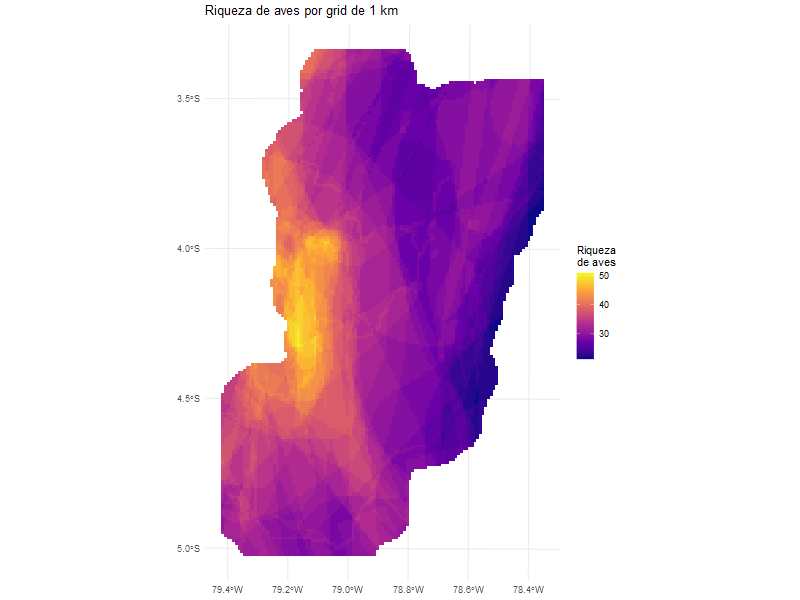

In [39]:

# Filtrar solo aves
birds_grid_species <- grid_species_df_complete %>%
  filter(Group == "Plantas") %>%
  mutate(
    grid_id = as.numeric(as.character(grid_id))
  )

# Calcular riqueza por grid
birds_richness_by_grid <- birds_grid_species %>%
  group_by(grid_id) %>%
  summarise(
    richness_birds = n_distinct(scientificName),
    .groups = "drop"
  )

# Asegurar mismo tipo en el shapefile
grids_1km_buffer <- grids_1km_buffer %>%
  mutate(
    id = as.numeric(id)
  )

# Unir riqueza al grid
grids_birds_richness <- grids_1km_buffer %>%
  left_join(birds_richness_by_grid, by = c("id" = "grid_id")) %>%
  mutate(
    richness_birds = ifelse(is.na(richness_birds), 0, richness_birds)
  )

# Mapa
ggplot(grids_birds_richness) +
  geom_sf(aes(fill = richness_birds), color = NA) +
  scale_fill_viridis_c(
    option = "plasma",
    name = "Riqueza\nde aves"
  ) +
  labs(
    title = "Riqueza de aves por grid de 1 km"
  ) +
  theme_minimal()